# Station-15 dehomogenization: RM shell 3-D stress vs VABS

This tutorial recovers the pointwise **3-D stress** in a thin-walled composite blade
cross-section from the **Reissner–Mindlin (RM) shell** cross-sectional model, and
compares it against **VABS** (the `.SM` 3-D stress recovery at the solid Gauss points).

It runs **entirely from data committed to this repository** — clone the repo and
execute top to bottom; nothing is read from a local machine.

**Inputs (all under `examples/data/`):**

| file | role |
|------|------|
| `1d_yaml/st15_shell.yaml` | the 1-D shell structure-gene (station 15, BAR-URC) |
| `benchmark/st15_vabs.K` | VABS Timoshenko 6×6 stiffness (homogenization benchmark) |
| `dehom_st15/bar_urc-15-t-0.in.SM` | VABS 3-D stress at the solid Gauss points (dehom benchmark) |
| `dehom_st15/solid.*.coords` | recovery paths (cap-centre, circumferential, left-edge) |

**The two-step MSG dehomogenization** (see `examples/TW-paper/xsec_paper/dehom_docs/`):
1. **beam force → shell strains** — invert the Timoshenko `6×6`, `st = C_eff⁻¹·FF`, and
   recover the 6 plate strains along the contour from the warping fields `V0, V1`.
2. **shell strains → 3-D stress** — reuse the *same* through-thickness plate-SG warping
   that built the ABD: `Σ(z) = C_layer·(B(z)·V0 + Ge(z))·ε`, energy-consistent with the
   homogenization (`∫Γ:Σ dz = εᵀ·ABD·ε`).

In [1]:
import os, sys
import numpy as np
os.environ["CUDA_VISIBLE_DEVICES"] = ""

def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and \
           os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        p = os.path.dirname(d)
        if p == d:
            raise RuntimeError("run this from inside the OpenSG-TW repo")
        d = p

CC = _find_repo_root()
sys.path.insert(0, CC)
import jax; jax.config.update("jax_enable_x64", True)
from opensg_jax.fe_jax import solve_tw_from_yaml, stress_at_points

DATA  = os.path.join(CC, "examples", "data")
SHELL = os.path.join(DATA, "1d_yaml", "st15_shell.yaml")
KF    = os.path.join(DATA, "benchmark", "st15_vabs.K")
DEH   = os.path.join(DATA, "dehom_st15")
print("repo root:", CC)

repo root: /home/roger/a/bagla0/OpenSG-TW-claude


## 1. Homogenization — RM shell Timoshenko 6×6 vs VABS `.K`

The RM shell is homogenized at the **OML reference** (`frac=0`).  We compare its
Timoshenko `6×6` against the VABS `.K` (both in section axes, VABS order
`[EA, GA2, GA3, GJ, EI2, EI3]`).  This station is a **thick spar cap**, so the
chordwise bending `EI3` is the hardest mode for a shell.

In [2]:
def load_vabs_timo(path):
    L = open(path).read().splitlines()
    i = next(k for k, ln in enumerate(L) if "Timoshenko Stiffness Matrix" in ln)
    rows = []
    for ln in L[i + 1:]:
        p = ln.split()
        ok = len(p) == 6
        try:
            [float(x) for x in p]
        except ValueError:
            ok = False
        if ok:
            rows.append([float(x) for x in p])
        if len(rows) == 6:
            break
    return np.array(rows)

K = load_vabs_timo(KF)
J = np.asarray(solve_tw_from_yaml(SHELL, frac=0.0)["Timo"])   # RM shell, OML reference
LBL = ["EA", "GA2", "GA3", "GJ", "EI2", "EI3"]
print("term      VABS .K        RM shell       %err")
for i in range(6):
    v, r = K[i, i], J[i, i]
    print("%-5s  %13.4e %13.4e   %+6.1f" % (LBL[i], v, r, 100*(r-v)/v))
fro = np.linalg.norm(J - K) / np.linalg.norm(K) * 100
print("full-6x6 Frobenius error = %.2f%%   (EI3 is the thick-cap chordwise-bending limit)" % fro)

term      VABS .K        RM shell       %err
EA        1.3083e+10    1.3326e+10     +1.9
GA2       4.5799e+08    4.4615e+08     -2.6
GA3       1.0550e+08    9.6268e+07     -8.8
GJ        1.5604e+08    1.5037e+08     -3.6
EI2       1.6630e+09    1.6716e+09     +0.5
EI3       5.1067e+09    5.8088e+09    +13.7
full-6x6 Frobenius error = 5.85%   (EI3 is the thick-cap chordwise-bending limit)


## 2. Dehomogenization — 3-D stress along two paths, RM shell vs VABS

We apply the station-15 beam force `FF` (VABS order), run the two-step recovery, and
compare the 6 stress components to VABS `.SM` (nearest Gauss point) along:

* **cap-centre through-thickness** — the recovery is valid (path ∥ the shell normal);
* **circumferential** — around the section on the shell surface.

(The **left-edge** path is included in the data as the *counter-example*: it runs down
the cap/web corner where the 1-D shell reference folds, so the through-thickness
projection collapses — see the discussion at the end.)

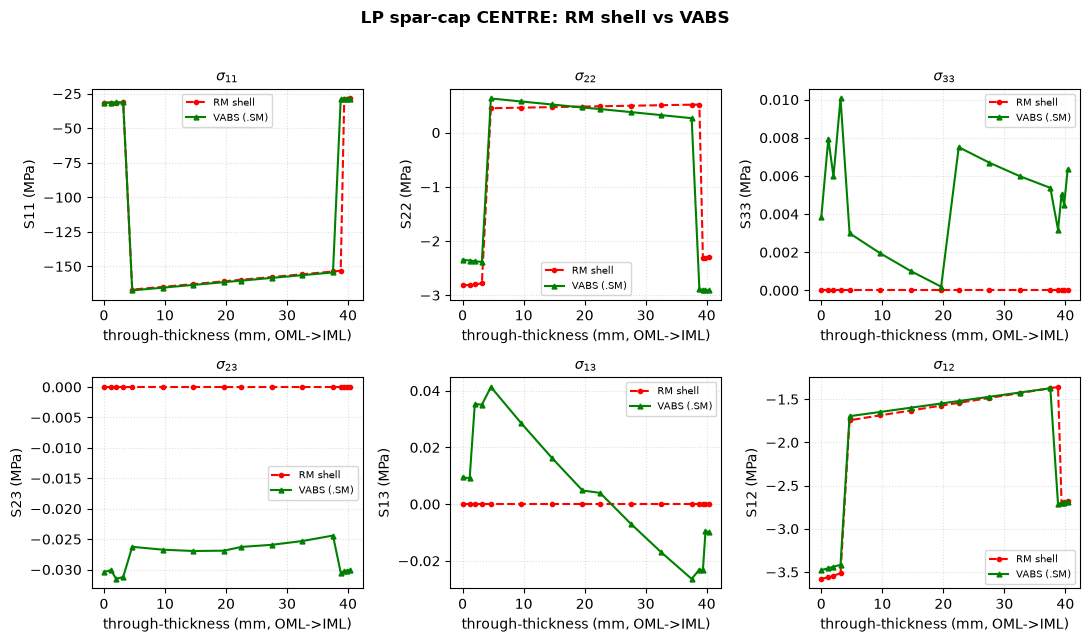

In [3]:
import matplotlib.pyplot as plt
COMP = ["S11", "S22", "S33", "S23", "S13", "S12"]
FF = np.array([32230.4005595904, -7663.907852209771, 251712.81004955297,
               -55608.54410550957, -4170203.8641732424, -123224.93244239496])

def load_sm(path):
    d = np.loadtxt(path)
    return d[:, :2], d[:, 2:8][:, [0, 3, 5, 4, 2, 1]]   # -> [S11,S22,S33,S23,S13,S12]

from scipy.spatial import cKDTree
sm_xy, sm_s = load_sm(os.path.join(DEH, "bar_urc-15-t-0.in.SM"))
tree = cKDTree(sm_xy)
bundle = solve_tw_from_yaml(SHELL, frac=0.0)

def dehom_path(coords_file, around=False):
    coords = np.loadtxt(os.path.join(DEH, coords_file))[:, :2]
    z = np.r_[0.0, np.cumsum(np.hypot(np.diff(coords[:,0]), np.diff(coords[:,1])))]
    S = np.asarray(stress_at_points(bundle, coords, beam_force_vabs=FF, frame="material")["stress"])
    V = sm_s[tree.query(coords)[1]]
    return (z if around else z*1e3), S, V

def plot_path(coords_file, xlabel, title, around=False):
    xs, S, V = dehom_path(coords_file, around)
    fig, ax = plt.subplots(2, 3, figsize=(11, 6.5)); fig.suptitle(title, fontweight="bold")
    for k, c in enumerate(COMP):
        a = ax.flat[k]
        a.plot(xs, S[:, k]/1e6, "r--o", ms=3, label="RM shell")
        a.plot(xs, V[:, k]/1e6, "g-^", ms=3.5, label="VABS (.SM)")
        a.set_title(r"$\sigma_{%s}$" % c[1:], fontsize=10)
        a.set_xlabel(xlabel); a.set_ylabel(c + " (MPa)"); a.grid(alpha=.4, ls=":"); a.legend(fontsize=7)
    fig.tight_layout(rect=(0,0,1,.96)); plt.show()

plot_path("solid.lp_sparcap_center_thickness_015.coords",
          "through-thickness (mm, OML->IML)",
          "LP spar-cap CENTRE: RM shell vs VABS")

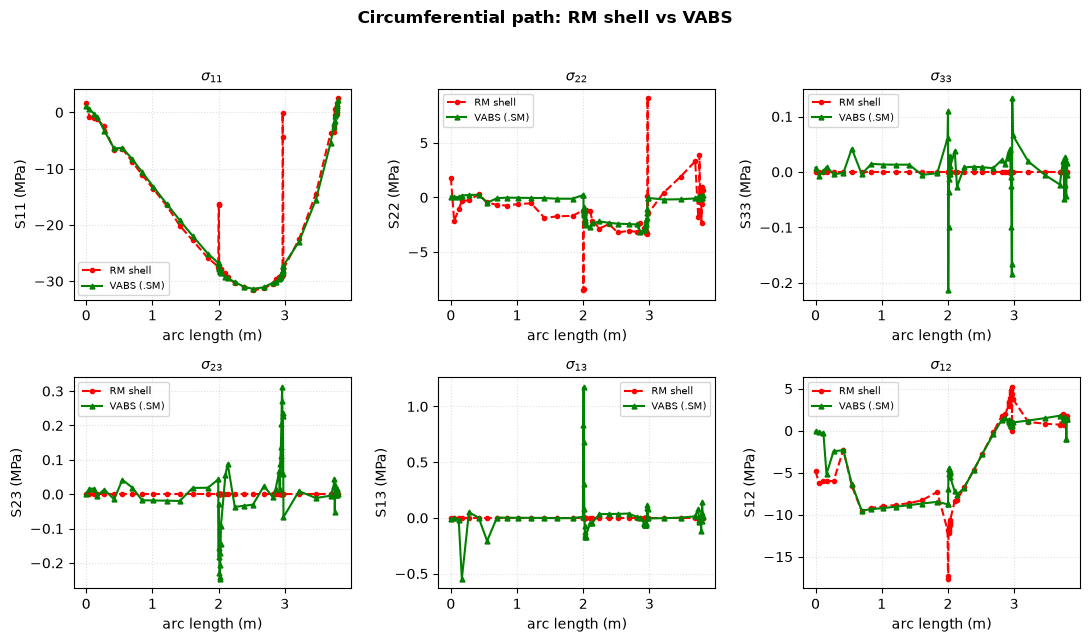

In [4]:
plot_path("solid.circumferential_015.coords", "arc length (m)",
          "Circumferential path: RM shell vs VABS", around=True)

## 3. What the plots show

* **In-plane** `σ11, σ22, σ12` from the RM shell **track VABS to <1%** through the cap
  thickness (peak `−167` MPa) and around the section — the energy-consistent MSG plate
  recovery. The one split on the cap-centre path is a single point straddling the
  cap/skin ply interface; on the circumferential path the spikes are the **web-junction**
  arc positions where the 1-D shell reference folds (topology, not a recovery error).
* **Out-of-plane** `σ33, σ13, σ23 ≈ 0` — the plate law used is the **6×6 Kirchhoff ABD**,
  and these components are ~`0.04` MPa vs `167` MPa in-plane (~4000× smaller). Recovering
  them physically needs the **RM 8×8** transverse-shear block; see below.
* **Left-edge path** (`solid.lp_sparcap_left_edge_thickness_015.coords`): try it — it is
  ~10× low in-plane because it runs down the cap/web corner where the shell reference
  folds, so a solid "thickness column" there is *not* a through-thickness line of the
  shell. Sample the cap interior instead.

## Further reading (in this repo)

* `examples/TW-paper/xsec_paper/dehom_docs/dehom_procedure.txt` — the full two-step
  algorithm, formulas, and the opensg-msg-expert rigor review.
* `examples/TW-paper/xsec_paper/dehom_docs/rm_8x8_homogenization.txt` — line-by-line MSG
  RM 8×8 plate homogenization and where the 2×2 transverse-shear `G` comes from
  (complementary-energy shear flow; Whitney 1973, in the RM plate model of Yu 2005).
* `examples/data/benchmark/st15_rm_plate_8x8.dat` — the RM 8×8 `[[A,B,0],[B,D,0],[0,0,G]]`
  for every st15 wall laminate.